In [9]:
import sys
!{sys.executable} -m pip install yfinance

  Using cached yfinance-1.2.0-py2.py3-none-any.whl.metadata (6.1 kB)
  Using cached multitasking-0.0.12.tar.gz (19 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached peewee-4.0.1-py3-none-any.whl.metadata (8.5 kB)
  Using cached beautifulsoup4-4.14.3-py3-none-any.whl.metadata (3.8 kB)
  Using cached curl_cffi-0.13.0-cp39-abi3-macosx_11_0_arm64.whl.metadata (13 kB)
  Using cached soupsieve-2.8.3-py3-none-any.whl.metadata (4.6 kB)
Using cached yfinance-1.2.0-py2.py3-none-any.whl (130 kB)
Using cached curl_cffi-0.13.0-cp39-abi3-macosx_11_0_arm64.whl (3.0 MB)
Using cached beautifulsoup4-4.14.3-py3-none-any.whl (107 kB)
Using cached peewee-4.0.1-py3-none-any.whl (139 kB)
Using cached soupsieve-2.8.3-py3-none-any.whl (37 kB)
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15637 sha256=06d70ad25320302590d44a5b77bacf39d225745de2df6bf54aa5618ac696d2d7
  Sto

In [19]:
pip install --upgrade pip

  Using cached pip-26.0.1-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-26.0.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 26.0
    Uninstalling pip-26.0:
      Successfully uninstalled pip-26.0
Note: you may need to restart the kernel to use updated packages.


In [21]:
pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 115.7 kB/s  0:01:05m0:00:0100:03
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 689.9 kB/s  0:00:04 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [22]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# download stock data
df = yf.download("AAPL", start="2022-01-01", end="2023-01-01")

# preview data
df.head()



[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,178.103668,178.955006,173.895967,174.013387,104487900
2022-01-04,175.843216,179.013683,175.275662,178.710339,99310400
2022-01-05,171.165863,176.303187,170.891874,175.755209,94537600
2022-01-06,168.308502,171.537680,167.956228,168.993476,96904000
2022-01-07,168.474884,170.402605,167.359351,169.179433,86709100


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2022-01-03 to 2022-12-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   251 non-null    float64
 1   (High, AAPL)    251 non-null    float64
 2   (Low, AAPL)     251 non-null    float64
 3   (Open, AAPL)    251 non-null    float64
 4   (Volume, AAPL)  251 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.8 KB


In [13]:
df1=df.reset_index()['Close']

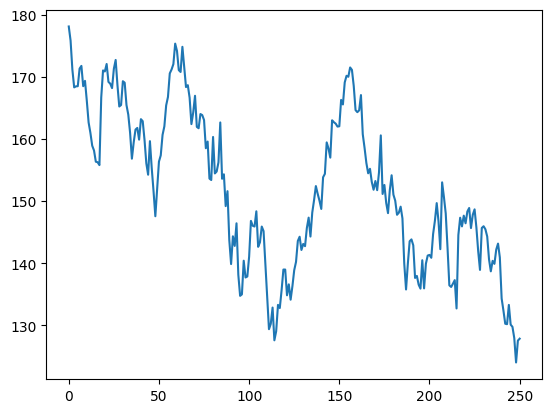

In [23]:
plt.plot(df1)

In [25]:
training_size = int(len(df1) * 0.65)
test_size = len(df1) - training_size

train_data = df1.iloc[0:training_size, :]
test_data = df1.iloc[training_size:len(df1), :]

In [26]:
training_size,test_size

(163, 88)

In [27]:
train_data

Ticker,AAPL
0,178.103668
1,175.843216
2,171.165863
3,168.308502
4,168.474884
...,...
158,168.533310
159,164.652130
160,164.318008
161,164.612823


In [28]:
def create_dataset(dataset, time_step=1):
	dataX, dataY = [], []
	for i in range(len(dataset)-time_step-1):
		a = dataset[i:(i+time_step), 0]   ###i=0, 0,1,2,3-----99   100 
		dataX.append(a)
		dataY.append(dataset[i + time_step, 0])
	return numpy.array(dataX), numpy.array(dataY)